# Which Wisdom Book Is This Passage From? Supervised Text Classification of Biblical and Asian Religious Texts

**Name:** Arturo Ramos
**Dataset:** *A Study of Asian Religious and Biblical Texts* (UCI Machine Learning Repository, 2019, CC BY 4.0) — https://doi.org/10.24432/C55S4W — file `AllBooks_baseline_DTM_Labelled.csv`

**Problem.** This is a **supervised learning, multi-class classification** task. Each row is a passage (a chapter-sized chunk) from one of eight wisdom books — four biblical (Proverbs, Ecclesiastes, Ecclesiasticus, Book of Wisdom) and four Asian (Upanishads, Yoga Sutras, Buddhist Sutras, Tao Te Ching) — represented by the counts of 8,266 words. The target is the book the passage comes from. The goal is to train a model that identifies the source book of an unseen passage from its vocabulary and to evaluate it honestly on data it never saw.

## 1. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             classification_report, confusion_matrix)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 160)

DATA_DIR = Path("data")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42

print("numpy", np.__version__, "| pandas", pd.__version__, "| scikit-learn", sklearn.__version__)

numpy 2.5.3 | pandas 3.0.6 | scikit-learn 1.9.1


## 2. Load and Inspect the Dataset

In [2]:
raw = pd.read_csv(DATA_DIR / "AllBooks_baseline_DTM_Labelled.csv")
print("shape:", raw.shape)
raw.iloc[:5, :8]

shape: (590, 8267)


,Unnamed: 0,foolishness,hath,wholesome,takest,feelings,anger,vaivaswata
0,Buddhism_Ch1,0,0,0,0,0,0,0
1,Buddhism_Ch2,0,0,0,0,0,0,0
2,Buddhism_Ch3,0,0,0,0,0,0,0
3,Buddhism_Ch4,0,0,0,0,0,0,0
4,Buddhism_Ch5,0,0,0,0,0,0,0


In [3]:
print("First column name:", repr(raw.columns[0]))
print("Example labels:", raw.iloc[:3, 0].tolist(), "...", raw.iloc[-2:, 0].tolist())
print()
print("Column data types:")
print(raw.dtypes.value_counts())
print()
print("Missing values in the whole table:", int(raw.isna().sum().sum()))

First column name: 'Unnamed: 0'
Example labels: ['Buddhism_Ch1', 'Buddhism_Ch2', 'Buddhism_Ch3'] ... ['BookOfWisdom_Ch18', 'BookOfWisdom_Ch19']

Column data types:
int64    8266
str         1
Name: count, dtype: int64



Missing values in the whole table: 0


In [4]:
counts = raw.iloc[:, 1:]
labels = raw.iloc[:, 0].str.split("_").str[0]
tokens = counts.sum(axis=1)

print("Passages per book (raw labels):")
print(labels.value_counts().to_string())
print()
print(f"sparsity (share of zero cells): {(counts == 0).to_numpy().mean():.4f}")
print(f"words that appear in only one passage: {int(((counts > 0).sum() == 1).sum()):,} of {counts.shape[1]:,}")
print(f"passages with zero words: {int((tokens == 0).sum())} -> {raw.loc[tokens == 0, raw.columns[0]].tolist()}")
print(f"words per passage: min {tokens.min()}, median {tokens.median():.0f}, max {tokens.max()}")
print()
print("median words per passage, by book:")
print(tokens.groupby(labels).median().sort_values().to_string())

Passages per book (raw labels):
Unnamed: 0
YogaSutra                189
Upanishad                162
TaoTeChing                81
BookOfEccleasiasticus     50
Buddhism                  46
BookOfProverb             31
BookOfWisdom              19
BookOfEcclesiastes        12



sparsity (share of zero cells): 0.9914


words that appear in only one passage: 3,872 of 8,266
passages with zero words: 1 -> ['Buddhism_Ch14']
words per passage: min 0, median 61, max 1194

median words per passage, by book:
Unnamed: 0
Upanishad                 26.0
TaoTeChing                53.0
YogaSutra                 58.0
Buddhism                 107.5
BookOfEcclesiastes       235.5
BookOfProverb            245.0
BookOfWisdom             260.0
BookOfEccleasiasticus    296.0


**Data quality notes**

- The table has 590 rows and 8,266 columns: an unnamed first column with a label such as `Buddhism_Ch1`, and 8,266 integer word counts. There are no missing values and all counts are non-negative integers, so no imputation is needed.
- The target is not a column of its own; it has to be parsed from the label (the part before `_Ch`). One of the book names is misspelled in the source (`BookOfEccleasiasticus`).
- One passage (`Buddhism_Ch14`) contains no words at all: it carries no information and is removed.
- The classes are strongly imbalanced, from 189 passages of the Yoga Sutras down to 12 of Ecclesiastes. Accuracy alone would reward a model that ignores the small biblical books.
- The matrix is extremely sparse (99.1 % zeros) and 3,872 words occur in a single passage, which is a high-dimensional, small-sample setting (8,266 features for 589 usable passages) where regularization matters.

## 3. Data Preparation and Preprocessing

In [5]:
BOOK_NAMES = {
    "BookOfEccleasiasticus": "Ecclesiasticus",   # misspelled in the source file
    "BookOfEcclesiastes": "Ecclesiastes",
    "BookOfProverb": "Proverbs",
    "BookOfWisdom": "Book of Wisdom",
    "Buddhism": "Buddhist Sutras",
    "TaoTeChing": "Tao Te Ching",
    "Upanishad": "Upanishads",
    "YogaSutra": "Yoga Sutras",
}
BIBLICAL = {"Ecclesiasticus", "Ecclesiastes", "Proverbs", "Book of Wisdom"}


def split_features_and_target(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series, pd.Series]:
    """Split the raw table into word-count features, a clean book label and the chunk id.

    The label column looks like ``"BookOfProverb_Ch3"``; the book is the part before
    ``"_Ch"`` and is mapped to a readable name (which also fixes the source's misspelling
    of Ecclesiasticus). Every label must map to a known book.
    """
    chunk_id = df.iloc[:, 0].rename("chunk_id")
    book = chunk_id.str.split("_").str[0].map(BOOK_NAMES).rename("book")
    assert book.notna().all(), "unknown book label in the source file"
    X = df.iloc[:, 1:].astype(int)
    return X, book, chunk_id


def drop_empty_passages(X: pd.DataFrame, *others: pd.Series) -> tuple:
    """Remove passages whose word counts are all zero (they carry no information)."""
    keep = X.sum(axis=1) > 0
    return (X.loc[keep],) + tuple(o.loc[keep] for o in others)

In [6]:
X_all, y_all, ids_all = split_features_and_target(raw)
X, y, ids = drop_empty_passages(X_all, y_all, ids_all)
print("features:", X.shape, "| target:", y.shape)
print(y.value_counts().to_string())

features: (589, 8266) | target: (589,)
book
Yoga Sutras        189
Upanishads         162
Tao Te Ching        81
Ecclesiasticus      50
Buddhist Sutras     45
Proverbs            31
Book of Wisdom      19
Ecclesiastes        12


In [7]:
# Hold out 25 % of the passages as a test set, stratified so every book keeps its proportion.
X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(
    X, y, ids, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
print("train:", X_train.shape, "| test:", X_test.shape)
pd.DataFrame({"train": y_train.value_counts(), "test": y_test.value_counts()})

train: (441, 8266) | test: (148, 8266)


,train,test
book,,
Yoga Sutras,142,47
Upanishads,121,41
Tao Te Ching,61,20
Ecclesiasticus,37,13
Buddhist Sutras,34,11
Proverbs,23,8
Book of Wisdom,14,5
Ecclesiastes,9,3


**What was done and why**

- **Target encoding.** The book is parsed from the label and given a readable name; scikit-learn classifiers accept string labels directly, so no numeric encoding is required.
- **Empty passage removed.** A passage with no words cannot be classified from its words.
- **Stratified train/test split (75/25).** With 12 Ecclesiastes passages, a plain random split could leave a book almost absent from the test set; stratification keeps 3 of them in the test set and 9 in training.
- **Feature scaling: TF-IDF instead of raw counts.** Passages differ a lot in length (Upanishad passages have a median of 26 words, while the four biblical books have medians between 236 and 296), so raw counts would mostly encode length. The TF-IDF transform uses sublinear term frequency (1 + log count), down-weights words that occur in many passages, and normalizes every passage to unit length. It is placed **inside a scikit-learn Pipeline** so that the document frequencies are learned from the training folds only, which prevents information from the validation and test passages leaking into training.
- **No feature selection by hand.** Rare words are kept; the model's regularization decides how much each word counts, and the regularization strength is tuned by cross-validation.

## 4. Model Selection and Training

Three models are compared with repeated stratified cross-validation (5 folds × 5 repetitions = 25 fits per setting) **on the training set only**, using the macro-averaged F1 score (the mean of the per-book F1 scores, so each book counts equally):

1. **Baseline** — always predicts the most frequent book. Any real model must beat it.
2. **Multinomial Naive Bayes** on raw counts — a classic, fast text classifier; the smoothing parameter `alpha` is tuned.
3. **Logistic Regression** on TF-IDF features — a linear model with L2 regularization and `class_weight="balanced"` (errors on small books cost more); the inverse regularization strength `C` is tuned.

In [8]:
# Repeating the 5-fold split 5 times averages out the luck of a single fold assignment,
# which matters when the smallest book has only 9 training passages.
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)

candidates = {
    "Baseline (most frequent)": (DummyClassifier(strategy="most_frequent"), {}),
    "Multinomial Naive Bayes": (MultinomialNB(), {"alpha": [0.01, 0.1, 0.5, 1.0]}),
    "Logistic Regression (TF-IDF)": (
        Pipeline([
            ("tfidf", TfidfTransformer(sublinear_tf=True)),
            ("clf", LogisticRegression(max_iter=5000, class_weight="balanced")),
        ]),
        {"clf__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10]},
    ),
}

searches, rows = {}, []
for name, (estimator, grid) in candidates.items():
    search = GridSearchCV(estimator, grid, cv=cv, scoring="f1_macro", return_train_score=True)
    search.fit(X_train, y_train)
    best = search.best_index_
    searches[name] = search
    rows.append({
        "model": name,
        "best params": search.best_params_ or "-",
        "CV macro-F1 (mean)": search.cv_results_["mean_test_score"][best],
        "CV macro-F1 (sd)": search.cv_results_["std_test_score"][best],
        "train macro-F1": search.cv_results_["mean_train_score"][best],
    })
cv_table = pd.DataFrame(rows).set_index("model").round(3)
cv_table

,best params,CV macro-F1 (mean),CV macro-F1 (sd),train macro-F1
model,,,,
Baseline (most frequent),-,0.061,0.001,0.061
Multinomial Naive Bayes,{'alpha': 0.01},0.872,0.051,1.000
Logistic Regression (TF-IDF),{'clf__C': 0.01},0.920,0.041,0.999


In [9]:
# How the regularization strength C affects cross-validated performance
lr_search = searches["Logistic Regression (TF-IDF)"]
pd.DataFrame({
    "C": lr_search.cv_results_["param_clf__C"],
    "CV macro-F1 (mean)": lr_search.cv_results_["mean_test_score"],
    "CV macro-F1 (sd)": lr_search.cv_results_["std_test_score"],
    "train macro-F1": lr_search.cv_results_["mean_train_score"],
}).round(3)

,C,CV macro-F1 (mean),CV macro-F1 (sd),train macro-F1
0,0.01,0.920,0.041,0.999
1,0.03,0.916,0.050,0.999
2,0.10,0.919,0.047,0.999
3,0.30,0.908,0.052,0.999
4,1.00,0.896,0.060,0.999
5,3.00,0.892,0.057,1.000
6,10.00,0.892,0.061,1.000


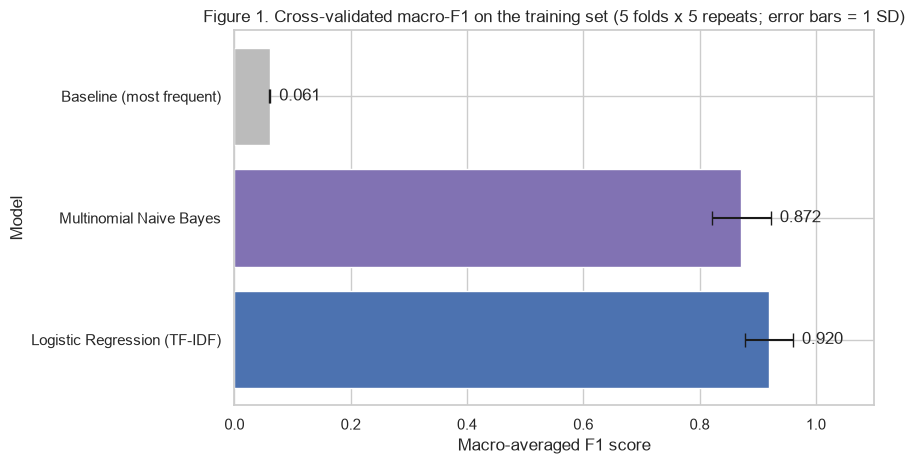

In [10]:
# Figure 1 — cross-validated comparison of the three models
fig, ax = plt.subplots(figsize=(9, 4.8))
order = cv_table.index.tolist()
ax.barh(order, cv_table["CV macro-F1 (mean)"], xerr=cv_table["CV macro-F1 (sd)"],
        color=["#BBBBBB", "#8172B3", "#4C72B0"], capsize=5)
for i, (m, s) in enumerate(zip(cv_table["CV macro-F1 (mean)"], cv_table["CV macro-F1 (sd)"])):
    ax.text(m + s + 0.015, i, f"{m:.3f}", va="center")
ax.set_xlim(0, 1.1)
ax.invert_yaxis()
ax.set_title("Figure 1. Cross-validated macro-F1 on the training set (5 folds x 5 repeats; error bars = 1 SD)")
ax.set_xlabel("Macro-averaged F1 score")
ax.set_ylabel("Model")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig1_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

**Training results.** Logistic regression on TF-IDF features is the best model in repeated cross-validation (mean macro-F1 0.920, SD 0.041), ahead of Naive Bayes (0.872) and far above the baseline (0.061), which only ever predicts the Yoga Sutras. Both real models reach a training score close to 1 (0.999 and 1.000), so they fit the training passages almost perfectly; with 8,266 features and 441 training passages that is expected, and the gap to the cross-validated score is the variance that regularization has to control. The search chose the strongest regularization tested (C = 0.01), but C = 0.1 scores 0.919 and C = 0.03 scores 0.916, so the model is not sensitive to the exact value within that range; weaker regularization (C of 1 or more) lowers the score to about 0.89. The standard deviations of 0.04–0.06 across folds show how much a single passage of a small book can move the macro-F1. The tuned logistic regression is selected and `GridSearchCV` refits it on the whole training set.

## 5. Evaluation on the Held-Out Test Set

In [11]:
model = searches["Logistic Regression (TF-IDF)"].best_estimator_
y_pred = pd.Series(model.predict(X_test), index=y_test.index)

summary = pd.DataFrame({
    name: {
        "accuracy": accuracy_score(y_test, s.best_estimator_.predict(X_test)),
        "balanced accuracy": balanced_accuracy_score(y_test, s.best_estimator_.predict(X_test)),
        "macro-F1": f1_score(y_test, s.best_estimator_.predict(X_test), average="macro"),
    }
    for name, s in searches.items()
}).T.round(3)
summary

,accuracy,balanced accuracy,macro-F1
Baseline (most frequent),0.318,0.125,0.060
Multinomial Naive Bayes,0.926,0.832,0.867
Logistic Regression (TF-IDF),0.939,0.887,0.863


In [12]:
print(classification_report(y_test, y_pred, digits=3, zero_division=0))

                 precision    recall  f1-score   support

 Book of Wisdom      0.667     0.800     0.727         5
Buddhist Sutras      0.786     1.000     0.880        11
   Ecclesiastes      0.667     0.667     0.667         3
 Ecclesiasticus      1.000     0.692     0.818        13
       Proverbs      0.727     1.000     0.842         8
   Tao Te Ching      1.000     1.000     1.000        20
     Upanishads      1.000     0.976     0.988        41
    Yoga Sutras      1.000     0.957     0.978        47

       accuracy                          0.939       148
      macro avg      0.856     0.887     0.863       148
   weighted avg      0.951     0.939     0.940       148



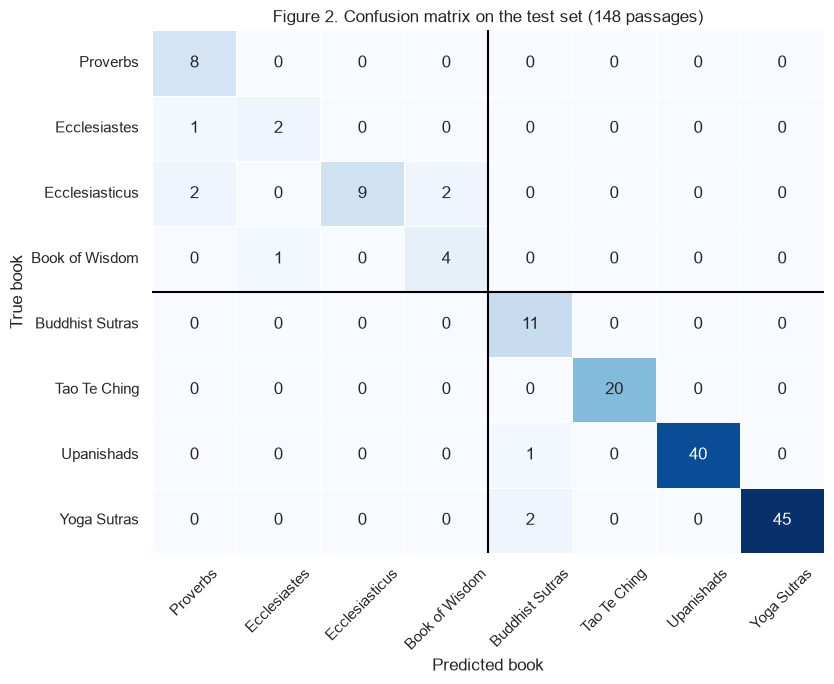

In [13]:
# Figure 2 — confusion matrix of the selected model on the test set
book_order = ["Proverbs", "Ecclesiastes", "Ecclesiasticus", "Book of Wisdom",
              "Buddhist Sutras", "Tao Te Ching", "Upanishads", "Yoga Sutras"]
cm = confusion_matrix(y_test, y_pred, labels=book_order)
fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=book_order, yticklabels=book_order,
            linewidths=0.5, linecolor="white", ax=ax)
ax.axhline(4, color="black", lw=1.5)
ax.axvline(4, color="black", lw=1.5)
ax.set_title("Figure 2. Confusion matrix on the test set (148 passages)")
ax.set_xlabel("Predicted book")
ax.set_ylabel("True book")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig2_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# Every misclassified passage, with its length
errors = pd.DataFrame({
    "passage": ids_test, "true book": y_test, "predicted": y_pred, "words in passage": X_test.sum(axis=1),
}).loc[y_test != y_pred].sort_values("passage")
print(f"misclassified: {len(errors)} of {len(y_test)} test passages")
errors

misclassified: 9 of 148 test passages


,passage,true book,predicted,words in passage
535,BookOfEccleasiasticus_Ch15,Ecclesiasticus,Proverbs,208
541,BookOfEccleasiasticus_Ch21,Ecclesiasticus,Proverbs,291
544,BookOfEccleasiasticus_Ch24,Ecclesiasticus,Book of Wisdom,400
564,BookOfEccleasiasticus_Ch44,Ecclesiasticus,Book of Wisdom,209
518,BookOfEcclesiastes_Ch10,Ecclesiastes,Proverbs,196
585,BookOfWisdom_Ch15,Book of Wisdom,Ecclesiastes,237
225,Upanishad_Ch99,Upanishads,Buddhist Sutras,16
307,YogaSutra_Ch19,Yoga Sutras,Buddhist Sutras,38
387,YogaSutra_Ch99,Yoga Sutras,Buddhist Sutras,58


In [15]:
# Collapsing the eight books into two groups: does the model ever confuse biblical and Asian texts?
true_group = y_test.isin(BIBLICAL).map({True: "Biblical", False: "Asian"})
pred_group = y_pred.isin(BIBLICAL).map({True: "Biblical", False: "Asian"})
print(f"accuracy at the level of biblical vs Asian: {accuracy_score(true_group, pred_group):.3f}")
print(f"median words per test passage: correct {X_test.sum(axis=1)[y_test == y_pred].median():.0f}, "
      f"misclassified {errors['words in passage'].median():.0f}")

accuracy at the level of biblical vs Asian: 1.000
median words per test passage: correct 57, misclassified 208


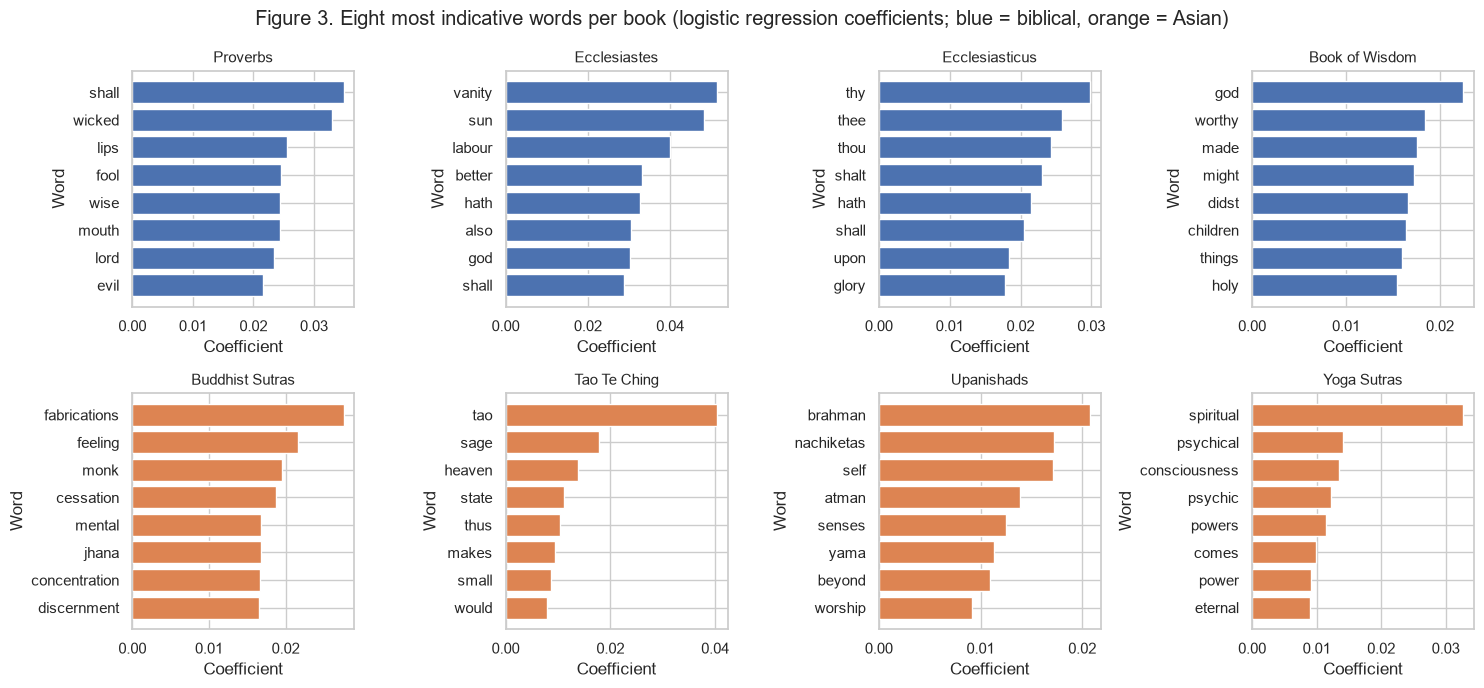

,Proverbs,Ecclesiastes,Ecclesiasticus,Book of Wisdom,Buddhist Sutras,Tao Te Ching,Upanishads,Yoga Sutras
0,shall,vanity,thy,god,fabrications,tao,brahman,spiritual
1,wicked,sun,thee,worthy,feeling,sage,nachiketas,psychical
2,lips,labour,thou,made,monk,heaven,self,consciousness
3,fool,better,shalt,might,cessation,state,atman,psychic
4,wise,hath,hath,didst,mental,thus,senses,powers
5,mouth,also,shall,children,jhana,makes,yama,comes
6,lord,god,upon,things,concentration,small,beyond,power
7,evil,shall,glory,holy,discernment,would,worship,eternal


In [16]:
# Figure 3 — the words with the largest positive coefficients for each book
clf = model.named_steps["clf"]
vocab = np.array(X.columns)
top_words = pd.DataFrame({book: vocab[np.argsort(clf.coef_[k])[::-1][:8]] for k, book in enumerate(clf.classes_)})[book_order]

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for ax, book in zip(axes.ravel(), book_order):
    k = list(clf.classes_).index(book)
    idx = np.argsort(clf.coef_[k])[::-1][:8]
    ax.barh(vocab[idx][::-1], clf.coef_[k][idx][::-1], color="#4C72B0" if book in BIBLICAL else "#DD8452")
    ax.set_title(book, fontsize=11)
    ax.set_xlabel("Coefficient")
    ax.set_ylabel("Word")
fig.suptitle("Figure 3. Eight most indicative words per book (logistic regression coefficients; blue = biblical, orange = Asian)")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig3_top_words.png", dpi=150, bbox_inches="tight")
plt.show()
top_words

### How stable is a single test score?

The test set has only 3 Ecclesiastes and 5 Book of Wisdom passages, so one passage more or less correct moves the macro-F1 by several points. To see how much of the test result is luck of the split, the two tuned models are re-trained and re-tested on 20 different stratified 75/25 splits (same hyperparameters, different random seeds).

In [17]:
lr_params = searches["Logistic Regression (TF-IDF)"].best_params_
nb_params = searches["Multinomial Naive Bayes"].best_params_
stability = []
for seed in range(20):
    Xa, Xb, ya, yb = train_test_split(X, y, test_size=0.25, stratify=y, random_state=seed)
    for name, est in [
        ("Logistic Regression (TF-IDF)", candidates["Logistic Regression (TF-IDF)"][0].set_params(**lr_params)),
        ("Multinomial Naive Bayes", MultinomialNB(**nb_params)),
    ]:
        stability.append({"seed": seed, "model": name, "test macro-F1": f1_score(yb, est.fit(Xa, ya).predict(Xb), average="macro")})
stability = pd.DataFrame(stability)
stability_summary = stability.groupby("model")["test macro-F1"].agg(["mean", "std", "min", "max"]).round(3)
wins = (stability.pivot(index="seed", columns="model", values="test macro-F1")
        .pipe(lambda t: (t["Logistic Regression (TF-IDF)"] > t["Multinomial Naive Bayes"]).sum()))
print(f"logistic regression beats Naive Bayes on {wins} of 20 splits")
stability_summary

logistic regression beats Naive Bayes on 15 of 20 splits


,mean,std,min,max
model,,,,
Logistic Regression (TF-IDF),0.911,0.038,0.830,0.969
Multinomial Naive Bayes,0.878,0.046,0.781,0.955


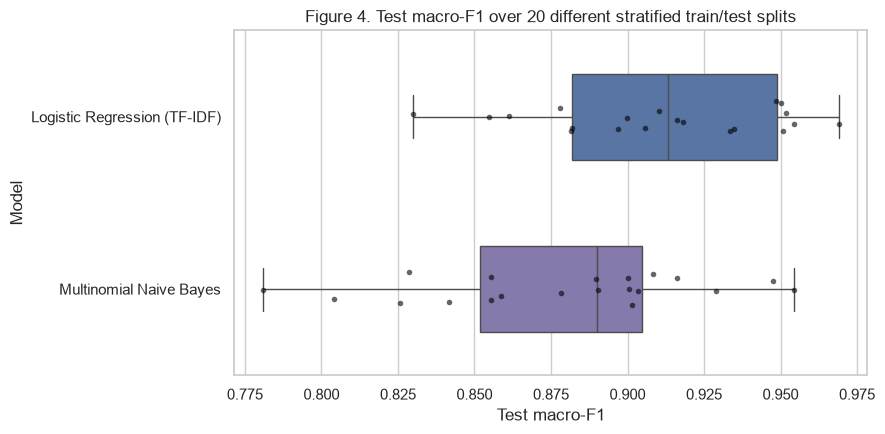

In [18]:
# Figure 4 — distribution of the test macro-F1 over 20 random splits
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=stability, x="test macro-F1", y="model", hue="model", palette=["#4C72B0", "#8172B3"], legend=False, width=0.5, ax=ax)
sns.stripplot(data=stability, x="test macro-F1", y="model", color="black", size=4, alpha=0.6, ax=ax)
ax.set_title("Figure 4. Test macro-F1 over 20 different stratified train/test splits")
ax.set_xlabel("Test macro-F1")
ax.set_ylabel("Model")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig4_split_stability.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Bias Check: Is the Model Reading Content or Translation Style?

All four biblical books come from an early-modern English translation, while the Asian texts come from modern translations. Figure 3 shows archaic forms such as *thy*, *thee*, *thou*, *shalt* and *hath* among the most indicative words for Ecclesiasticus and Ecclesiastes. If the model separated the two traditions mainly by these forms, it would be learning *translation style* rather than content. The check below measures how common these forms are per book, then removes them and retrains the same model with the same procedure.

In [19]:
ARCHAIC_PRONOUNS_AND_AUXILIARIES = {
    "thee", "thou", "thy", "thine", "ye", "hath", "hast", "doth", "dost", "art",
    "shalt", "wilt", "canst", "wouldst", "shouldst", "didst", "unto",
}


def archaic_columns(columns) -> list[str]:
    """Return the archaic English forms present in the vocabulary.

    Archaic forms are the listed pronouns and auxiliaries plus third-person verb forms
    ending in "-eth" (e.g. "giveth", "knoweth"); a few ordinary words that happen to end
    in "-eth" are excluded.
    """
    ordinary = {"teeth", "beneath", "seth", "heth", "japheth", "elizabeth", "nazareth", "twentieth", "thirtieth"}
    return sorted(w for w in columns
                  if w in ARCHAIC_PRONOUNS_AND_AUXILIARIES or (w.endswith("eth") and len(w) > 4 and w not in ordinary))

In [20]:
archaic = archaic_columns(X.columns)
has_archaic = (X[archaic].sum(axis=1) > 0)
print(f"archaic forms found in the vocabulary: {len(archaic)} (e.g. {archaic[:6]})")
print("share of passages containing at least one archaic form, per book:")
print(has_archaic.groupby(y).mean().reindex(book_order).round(2).to_string())

archaic forms found in the vocabulary: 404 (e.g. ['abateth', 'abhorreth', 'abideth', 'aboundeth', 'abstaineth', 'addeth'])
share of passages containing at least one archaic form, per book:
book
Proverbs           1.00
Ecclesiastes       1.00
Ecclesiasticus     1.00
Book of Wisdom     1.00
Buddhist Sutras    0.00
Tao Te Ching       0.06
Upanishads         0.23
Yoga Sutras        0.10


In [21]:
X_train_na, X_test_na = X_train.drop(columns=archaic), X_test.drop(columns=archaic)
search_na = GridSearchCV(candidates["Logistic Regression (TF-IDF)"][0], candidates["Logistic Regression (TF-IDF)"][1],
                         cv=cv, scoring="f1_macro").fit(X_train_na, y_train)
y_pred_na = search_na.predict(X_test_na)
group_na = pd.Series(y_pred_na, index=y_test.index).isin(BIBLICAL).map({True: "Biblical", False: "Asian"})

pd.DataFrame({
    "features": [X_train.shape[1], X_train_na.shape[1]],
    "best C": [lr_search.best_params_["clf__C"], search_na.best_params_["clf__C"]],
    "CV macro-F1": [lr_search.best_score_, search_na.best_score_],
    "test accuracy": [accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred_na)],
    "test macro-F1": [f1_score(y_test, y_pred, average="macro"), f1_score(y_test, y_pred_na, average="macro")],
    "biblical vs Asian accuracy": [accuracy_score(true_group, pred_group), accuracy_score(true_group, group_na)],
}, index=["all words", "archaic forms removed"]).round(3)

,features,best C,CV macro-F1,test accuracy,test macro-F1,biblical vs Asian accuracy
all words,8266,0.01,0.920,0.939,0.863,1.0
archaic forms removed,7862,0.10,0.936,0.966,0.930,1.0


## 7. Summary

I modeled a supervised, multi-class classification problem: identifying which of eight wisdom books (four biblical and four Asian) a passage comes from, using the word counts of 589 passages. I selected a logistic regression on TF-IDF features with balanced class weights and strong L2 regularization, chosen by repeated stratified cross-validation (macro-F1 0.920) over Multinomial Naive Bayes (0.872) and a majority-class baseline (0.061). On the held-out test set it reached an accuracy of 0.939 and a macro-F1 of 0.863, never confused a biblical passage with an Asian one, and made its errors among closely related books, mostly the three proverb-style biblical books. The main challenges were the strong class imbalance and the very small number of passages for Ecclesiastes and the Book of Wisdom, which make a single test score unstable (the macro-F1 ranged from 0.830 to 0.969 over 20 random splits). A bias check showed that archaic forms such as thee, thou and hath appear in every biblical passage, but removing all 404 of them did not reduce performance (test macro-F1 0.930), so the model relies on content words and not only on translation style.